    **Lab 10-02: การจำแนกประเภทรูปภาพ (Image Classification)**

```
Praisan Padungweang, CP, KKU, 2025
```

-----

    **Dataset และ DataLoader?**

ในการฝึกสอนโมเดล Deep Learning โดยเฉพาะโมเดลประเภท **Convolutional Neural Network (CNN)** ซึ่งประมวลผลข้อมูลรูปภาพขนาดใหญ่ โค้ดที่เกี่ยวข้องกับการโหลด จัดการ และป้อนข้อมูลเข้าสู่โมเดลอาจซับซ้อนและเกิดปัญหาคอขวด (bottleneck) ได้ PyTorch จึงมีเครื่องมือสำคัญ 2 อย่างเพื่อช่วยให้กระบวนการนี้เป็นมาตรฐานและมีประสิทธิภาพ:

1.  **`torch.utils.data.Dataset`**: เป็น abstract class สำหรับ "ห่อหุ้ม" ชุดข้อมูลของเรา ทำหน้าที่กำหนดวิธีการเข้าถึงข้อมูลแต่ละชิ้น (เช่น รูปภาพและป้ายกำกับ) ผ่าน index (เช่น `dataset[0]`) เปรียบเสมือนแคตตาล็อกที่ระบุว่าข้อมูลชิ้นที่ *n* อยู่ที่ไหนและคืออะไร

2.  **`torch.utils.data.DataLoader`**: เป็นเครื่องมือที่นำ `Dataset` มาสร้าง iterator เพื่อดึงข้อมูลออกมาป้อนโมเดลอย่างเป็นระบบและมีประสิทธิภาพ โดยมีความสามารถที่สำคัญอย่างยิ่งสำหรับงาน CNN เช่น:

      * **Batching**: การรวมข้อมูลหลายรูปภาพเป็นชุดเล็กๆ (batch) เพื่อป้อนเข้าโมเดลในครั้งเดียว ช่วยให้การฝึกสอนมีเสถียรภาพและใช้ประโยชน์จากหน่วยประมวลผลกราฟิก (GPU) ได้เต็มประสิทธิภาพ
      * **Shuffling**: การสุ่มลำดับข้อมูลในแต่ละรอบการฝึก (epoch) เพื่อป้องกันไม่ให้โมเดลเรียนรู้ลำดับของข้อมูลโดยไม่ได้ตั้งใจ ซึ่งเป็นปัจจัยสำคัญในการเพิ่มประสิทธิภาพโดยรวม
      * **Parallel Loading**: การใช้หน่วยประมวลผลกลาง (CPU) หลายแกน (multi-processing) เพื่อโหลดและประมวลผลรูปภาพล่วงหน้าไปพร้อมๆ กับที่ GPU กำลังฝึกสอนโมเดล ทำให้ลดระยะเวลารอคอยและเร่งกระบวนการฝึกสอนให้เร็วขึ้น

การใช้สองคลาสนี้ร่วมกันจะทำให้โค้ดสะอาด อ่านง่าย และสามารถจัดการกับชุดข้อมูลรูปภาพขนาดใหญ่ได้อย่างมีประสิทธิภาพ

-----

    **ส่วนที่ 1: การตั้งค่าและนำเข้าไลบรารี**

เริ่มต้นด้วยการ import ไลบรารีที่จำเป็นทั้งหมด และตั้งค่าสภาพแวดล้อมเพื่อดาวน์โหลดชุดข้อมูล

In [1]:
  Installation and file management
! pip install -q kaggle
import os
import zipfile

  PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

  Data manipulation and visualization
import pandas as pd
import numpy as np
from PIL import Image   Python Imaging Library for opening images
import matplotlib.pyplot as plt
import seaborn as sns

  Scikit-learn for preprocessing and data splitting
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

  ตรวจสอบและกำหนดอุปกรณ์ประมวลผล (GPU หรือ CPU)
  การใช้ 'cuda' (GPU) จะช่วยเร่งความเร็วในการฝึกสอนโมเดลได้อย่างมีนัยสำคัญ
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device ที่ใช้งานได้คือ: {device}')


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\ChxraWish\anaconda3\envs\nvidiaGPU_ForVoiceGenTraining\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device ที่ใช้งานได้คือ: cuda


-----

    **ส่วนที่ 2: การเตรียมข้อมูล (Image Data)**

ในส่วนนี้ เราจะใช้ชุดข้อมูลภาพ CT Scan ของผู้ป่วยโควิด-19 ซึ่งเป็นโจทย์ Image Classification

**ขั้นตอน:**

1.  **อัปโหลด Kaggle API Token:** ไปที่บัญชี [Kaggle](https://www.kaggle.com/settings) \> Account \> API \> "Create New API Token" เพื่อดาวน์โหลดไฟล์ `kaggle.json` เพื่อให้สามารถดาวน์โหลดชุดข้อมูลจาก Kaggle ได้โดยตรง
2.  **ดาวน์โหลดข้อมูล:** ใช้ Kaggle API เพื่อดาวน์โหลดชุดข้อมูล
3.  **แตกไฟล์:** แตกไฟล์ .zip ที่ดาวน์โหลดมา
4.  **สร้าง DataFrame:** รวบรวมที่อยู่ (path) ของไฟล์รูปภาพและป้ายกำกับ (label) มาเก็บไว้ใน `pandas.DataFrame` เพื่อให้ง่ายต่อการจัดการ
5.  **แปลง Label:** แปลงป้ายกำกับที่เป็นข้อความ (เช่น 'Covid', 'Healthy') ให้เป็นตัวเลขจำนวนเต็ม (0, 1, 2) เนื่องจากโมเดล Deep Learning ต้องการข้อมูลนำเข้าที่เป็นตัวเลขทั้งหมด

<!-- end list -->

In [ ]:

  2. ดาวน์โหลด dataset
  dataset_name = "plameneduardo/a-covid-multiclass-dataset-of-ct-scans"
  os.system(f"kaggle datasets download -d {dataset_name} -f a-covid-multiclass-dataset-of-ct-scans.zip")

  import opendatasets as od

  dataset = 'https://www.kaggle.com/plameneduardo/a-covid-multiclass-dataset-of-ct-scans'
  od.download(dataset, data_dir='dataset')    จะโหลดและแตกไฟล์ให้อัตโนมัติ


  3. แตกไฟล์ .zip
  zip_path = 'dataset/a-covid-multiclass-dataset-of-ct-scans.zip'
  extract_folder = 'dataset'

  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_folder)

  print(f"Dataset ถูกแตกไฟล์ไปที่: {extract_folder}")

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/a-covid-multiclass-dataset-of-ct-scans.zip'

In [2]:
  4. รวบรวม Path และ Label ทั้งหมด
image_paths = []
labels = []
data_dir = 'dataset\\a-covid-multiclass-dataset-of-ct-scans\\New_Data_CoV2'

for dirname, _, filenames in os.walk(data_dir):
    for filename in filenames:
        if filename.endswith('.png'):
            image_paths.append(os.path.join(dirname, filename))
              ดึงชื่อ class จากชื่อโฟลเดอร์
            parent_dirname = os.path.basename(os.path.dirname(dirname))
            labels.append(parent_dirname)

  สร้าง DataFrame เพื่อใช้เป็นโครงสร้างหลักในการจัดการข้อมูล
  ซึ่งช่วยให้การเข้าถึง การแบ่ง และการจัดการข้อมูลอ้างอิงทำได้สะดวก
df = pd.DataFrame({'path': image_paths, 'label': labels})

  5. แปลง Label ที่เป็น String ให้เป็นตัวเลข (Integer Encoding)
le = LabelEncoder()   khởi tạo đối tượng LabelEncoder
df['label_encoded'] = le.fit_transform(df['label'])   แปลงคอลัมน์ 'label' และสร้างคอลัมน์ใหม่

print("Class Mappings:")
  แสดงการจับคู่ระหว่างค่าตัวเลขและชื่อคลาสเพื่อการอ้างอิงในภายหลัง
for i, class_name in enumerate(le.classes_):
    print(f"{i}: {class_name}")

  แบ่งข้อมูลเป็น training (80%) และ testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    df['path'],
    df['label_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_encoded']   พารามิเตอร์ stratify เพื่อรับประกันว่าสัดส่วนของแต่ละคลาสในชุด train และ test จะเท่ากับสัดส่วนในข้อมูลตั้งต้น
)

print(f"\nจำนวนข้อมูล Train: {len(X_train)} รูป")
print(f"จำนวนข้อมูล Test: {len(X_test)} รูป")

Class Mappings:
0: Covid
1: Healthy
2: Others

จำนวนข้อมูล Train: 3336 รูป
จำนวนข้อมูล Test: 835 รูป


label
Covid      2167
Others     1247
Healthy     757
Name: count, dtype: int64


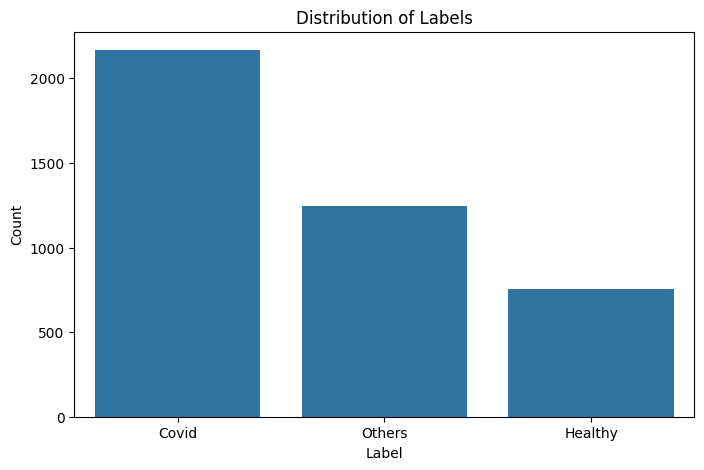

In [3]:
label_counts = df['label'].value_counts()
print(label_counts)

  วาดกราฟด้วย seaborn
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='label', order=label_counts.index)
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

    Hands-on: สำรวจชุดข้อมูล (Dataset Exploration)

**คำถาม (ง่าย):**
ชุดข้อมูลของเรามีความสมดุลหรือไม่? (จำนวนรูปภาพในแต่ละคลาสเท่ากันหรือไม่)

ตอบ ไม่สมดุลกัน เพราะจำนวนรูปภาพในแต่ละคลาสไม่เท่ากัน

* **แนวคิด:** การทำความเข้าใจการกระจายตัวของข้อมูล (Data Distribution) เป็นขั้นตอนแรกที่สำคัญมาก หากข้อมูลไม่สมดุล (Imbalanced Dataset) โมเดลอาจจะเอนเอียงไปทำนายคลาสที่มีข้อมูลเยอะกว่าได้
* **ทดลอง:** เขียนโค้ดเพื่อนับจำนวนรูปภาพในแต่ละคลาสโดยใช้ `pandas` และแสดงผลเป็นกราฟแท่ง (Bar Chart) เพื่อให้เห็นภาพรวมได้ชัดเจน
* **คำใบ้:** ใช้ `df['label'].value_counts()` เพื่อนับจำนวน และใช้ `seaborn.countplot()` หรือ `matplotlib.pyplot.bar()` ในการวาดกราฟ

-----

    **ส่วนที่ 3: การสร้าง Custom Dataset**

เราจะสร้างคลาส `Dataset` ของเราเอง โดยต้อง implement 3 เมธอดที่สำคัญ:

1.  **`__init__(self, ...)`**: Constructor ของคลาส ใช้สำหรับรับข้อมูลเข้ามาเก็บไว้เป็น attribute ของ object
2.  **`__len__(self)`**: คืนค่าเป็น **จำนวนทั้งหมด** ของข้อมูลในชุดข้อมูล
3.  **`__getitem__(self, idx)`**: **ดึงข้อมูล 1 ชิ้น** ณ ตำแหน่ง (index) `idx` ที่ระบุ ซึ่งเป็นหัวใจสำคัญในการเชื่อมต่อข้อมูลกับโมเดล
      * เปิดไฟล์รูปภาพจาก path
      * แปลงรูปภาพ (ถ้าจำเป็น)
      * ดึง label ที่คู่กัน
      * คืนค่าออกมาเป็น `(image, label)`

<!-- end list -->

In [4]:
class CustomImageDataset(Dataset):
    """
    คลาส Dataset แบบกำหนดเองซึ่งสืบทอดจาก torch.utils.data.Dataset
    เพื่อจัดการการโหลดรูปภาพและป้ายกำกับ
    """
    def __init__(self, image_paths, labels, transform=None):
        """
        Constructor ของคลาส
        :param image_paths: Series หรือ List ที่เก็บที่อยู่ของไฟล์รูปภาพ
        :param labels: Series หรือ List ที่เก็บป้ายกำกับที่สอดคล้องกัน
        :param transform: อ็อบเจกต์ transform จาก torchvision ที่จะนำไปใช้กับรูปภาพ
        """
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        """
        เมธอดที่คืนค่าจำนวนตัวอย่างทั้งหมดในชุดข้อมูล
        DataLoader จะเรียกใช้เมธอดนี้เพื่อกำหนดจำนวนข้อมูลทั้งหมด
        """
        return len(self.labels)

    def __getitem__(self, idx):
        """
        เมธอดที่ดึงข้อมูลหนึ่งตัวอย่างตามดัชนี (idx) ที่กำหนด
        :param idx: ดัชนีของข้อมูลที่ต้องการ
        :return: tuple (image, label) ที่ผ่านการประมวลผลแล้ว
        """
          ดึงที่อยู่ของรูปภาพและป้ายกำกับ ณ ดัชนีที่ระบุ
          การใช้ .iloc เป็นวิธีที่เหมาะสมสำหรับ pandas Series เพื่อการเข้าถึงข้อมูลตามตำแหน่งอย่างมีประสิทธิภาพ
        img_path = self.image_paths.iloc[idx]
        label = self.labels.iloc[idx]

          เปิดไฟล์รูปภาพและแปลงให้เป็นรูปแบบ RGB
          .convert('RGB') เป็นขั้นตอนที่สำคัญอย่างยิ่งเพื่อรับประกันว่ารูปภาพทุกรูปมี 3 channels (สี)
          ซึ่งเป็นมิติข้อมูลที่โมเดล CNN ส่วนใหญ่คาดหวัง และป้องกันข้อผิดพลาดจากรูปภาพขาว-ดำ (1 channel)
        image = Image.open(img_path).convert('RGB')

          หากมีการกำหนด transform ให้ดำเนินการแปลงรูปภาพ
        if self.transform:
            image = self.transform(image)   การแปลงนี้จะเปลี่ยนภาพ PIL เป็น Tensor และทำการ Augmentation

        return image, torch.tensor(label, dtype=torch.long)   คืนค่ารูปภาพในรูปแบบ Tensor และป้ายกำกับ

-----

    **ส่วนที่ 4: การแปลงข้อมูล (Transforms) และการเพิ่มข้อมูล (Data Augmentation)**

**Data Augmentation** คือเทคนิคการดัดแปลงรูปภาพต้นฉบับแบบสุ่ม (เช่น พลิก, หมุน) เพื่อสร้างข้อมูลใหม่ๆ สำหรับการฝึกสอน ทำให้โมเดล CNN เรียนรู้คุณลักษณะที่สำคัญของวัตถุได้ดีขึ้นและลดปัญหา Overfitting

In [5]:
  สร้าง Transforms สำหรับชุด Train (มีการทำ Data Augmentation)
train_transform = transforms.Compose([
      1. ปรับขนาดรูปภาพให้เป็น 224x224 pixels
      เพื่อให้รูปภาพทุกรูปมีขนาดเท่ากัน ซึ่งเป็นข้อกำหนดของโมเดล CNN ส่วนใหญ่
    transforms.Resize((224, 224)),
      2. สุ่มพลิกภาพในแนวนอน (Horizontal Flip) ด้วยความน่าจะเป็น 50%
      เป็นเทคนิค Augmentation พื้นฐานที่ช่วยให้โมเดลเรียนรู้โดยไม่ยึดติดกับทิศทางของวัตถุ
    transforms.RandomHorizontalFlip(p=0.5),
      3. สุ่มหมุนภาพเล็กน้อย (ไม่เกิน 15 องศา)
      เพื่อให้โมเดลมีความทนทานต่อการหมุนของวัตถุในภาพ
    transforms.RandomRotation(degrees=15),
      4. แปลงภาพ PIL (ค่า 0-255) เป็น PyTorch Tensor (ค่า 0.0-1.0)
      พร้อมทั้งสลับลำดับมิติจาก (H, W, C) เป็น (C, H, W) ตามรูปแบบที่ PyTorch ต้องการ
    transforms.ToTensor(),
      5. ปรับค่าสีของแต่ละ channel (Normalization)
      โดยใช้ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานของชุดข้อมูล ImageNet
      เพื่อให้ข้อมูลมีลักษณะใกล้เคียงกับข้อมูลที่โมเดล pre-trained เคยเรียนรู้มา
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

  สร้าง Transforms สำหรับชุด Test (ไม่มี Data Augmentation)
  ในขั้นตอนการประเมินผล จะไม่มีการดัดแปลงข้อมูลแบบสุ่ม เพื่อวัดประสิทธิภาพบนข้อมูลจริง
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

-----

    **ส่วนที่ 5: การใช้งาน DataLoader**

นำ `Dataset` และ `transforms` มาประกอบใน `DataLoader` เพื่อเตรียมป้อนข้อมูลให้โมเดล

**พารามิเตอร์ที่สำคัญของ DataLoader:**

  - `dataset`: object ของ `Dataset` ที่เราสร้างขึ้น
  - `batch_size`: จำนวนข้อมูลที่จะดึงออกมาในแต่ละครั้ง (1 batch)
  - `shuffle`: `True` สำหรับข้อมูลเทรน เพื่อสลับลำดับข้อมูลในแต่ละ epoch, `False` สำหรับข้อมูลเทส
  - `num_workers`: จำนวน CPU core ที่จะใช้โหลดข้อมูลแบบคู่ขนาน (การตั้งค่า > 0 จะช่วยให้การโหลดข้อมูลเร็วขึ้นมาก)

In [6]:
  1. สร้าง Dataset instances
train_dataset = CustomImageDataset(X_train, y_train, transform=train_transform)
test_dataset = CustomImageDataset(X_test, y_test, transform=test_transform)

BATCH_SIZE = 32

  2. สร้าง DataLoader instances
  สำหรับ Train: shuffle=True เพื่อให้โมเดลเห็นข้อมูลในลำดับที่ต่างกันไปในแต่ละ epoch ซึ่งช่วยลดความเสี่ยงของการเกิด overfitting
  num_workers > 0 จะเปิดใช้งาน multi-processing เพื่อโหลดข้อมูลล่วงหน้า ทำให้การฝึกสอนเร็วขึ้น
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count())

  สำหรับ Test: shuffle=False เนื่องจากลำดับของข้อมูลไม่มีผลต่อการประเมินผล
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count())

     ลองดึงข้อมูลจาก DataLoader

เราสามารถใช้ `next(iter(dataloader))` เพื่อดึงข้อมูลออกมา 1 batch และตรวจสอบรูปร่าง (shape) ของข้อมูลได้

In [ ]:
  ลองดึงข้อมูลมา 1 batch จาก train_loader เพื่อตรวจสอบ
images, labels = next(iter(train_loader))

  Shape ของ Image batch: torch.Size([32, 3, 224, 224])
  หมายความว่า ใน 1 batch ประกอบด้วย 32 รูป, แต่ละรูปมี 3 channels (RGB), และมีขนาด 224x224 pixels
  ซึ่งเป็นรูปแบบ Tensor ที่พร้อมป้อนเข้าสู่โมเดล CNN
print(f"Shape ของ Image batch: {images.shape}")
print(f"Shape ของ Label batch: {labels.shape}")

**ข้อสังเกต:** Shape ของ `images` คือ `[32, 3, 224, 224]` หมายความว่าใน 1 batch นี้มี **32** รูป, แต่ละรูปมี **3** channels (RGB), และมีขนาด **224x224** pixels ซึ่งสอดคล้องกับค่า `BATCH_SIZE` และ `transforms` ที่เรากำหนดไว้

    Hands-on: DataLoader

**คำถาม (ง่าย):**
จะเกิดอะไรขึ้นกับ shape ของ output ถ้าเราเปลี่ยน `BATCH_SIZE`?

* **ทดลอง:** ในเซลล์โค้ดที่สร้าง `DataLoader` ลองเปลี่ยนค่า `BATCH_SIZE` จาก `32` เป็น `64`
* **รันใหม่:** รันเซลล์ที่สร้าง `DataLoader` และเซลล์ที่ใช้ `next(iter(...))` อีกครั้ง
* **สังเกต:** Shape ของ `Image batch` เปลี่ยนไปอย่างไร? ตัวเลขแรกของ shape สัมพันธ์กับ `BATCH_SIZE` ที่เราตั้งไว้อย่างไร?

-----

    **ส่วนที่ 6: สร้างโมเดลและ Training Loop**

เราจะใช้สถาปัตยกรรม **VGG16** ซึ่งเป็น **Convolutional Neural Network (CNN)** ที่มีชื่อเสียง และใช้เทคนิค **Transfer Learning** โดยการนำโมเดลที่ผ่านการฝึกสอนบนชุดข้อมูล ImageNet มาแล้ว และปรับแก้เฉพาะส่วนท้าย (Classifier) ให้เข้ากับโจทย์ของเรา

In [7]:
  โหลดโมเดล VGG16 พร้อมน้ำหนักที่ผ่านการฝึกสอนบน ImageNet (Pre-trained weights)
  การใช้ pre-trained model ช่วยให้โมเดลเรียนรู้ได้เร็วขึ้นและมีประสิทธิภาพสูงขึ้น แม้จะมีข้อมูลจำกัด
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

  "แช่แข็ง" (freeze) พารามิเตอร์ในส่วนของ feature extractor (convolutional layers)
  เพื่อไม่ให้ค่า weight เหล่านี้เปลี่ยนแปลงในระหว่างการฝึกสอน และเก็บความรู้เดิมไว้
for param in model.features.parameters():
    param.requires_grad = False

  แก้ไขชั้นสุดท้าย (classifier) ให้มีจำนวน output เท่ากับจำนวนคลาสของเรา
num_classes = len(le.classes_)
in_features = model.classifier[6].in_features   ดึงจำนวน features ขาเข้าของชั้นสุดท้ายเดิม
  สร้างชั้น Linear ใหม่เพื่อแทนที่ชั้นสุดท้ายของ VGG16
  โดยจะมีการฝึกสอนเฉพาะพารามิเตอร์ของชั้นใหม่นี้เท่านั้น
model.classifier[6] = nn.Linear(in_features, num_classes)

  ส่งโมเดลไปทำงานบน device ที่เลือกไว้ (GPU/CPU)
model = model.to(device)

  กำหนด Optimizer (Adam) สำหรับปรับปรุงน้ำหนักของโมเดล
  เราส่ง model.parameters() เพื่อให้ optimizer จัดการเฉพาะพารามิเตอร์ที่ requires_grad=True (คือชั้น classifier ที่เราสร้างใหม่)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

  กำหนด Loss function (CrossEntropyLoss) ซึ่งเหมาะสำหรับโจทย์ Multi-class classification
criterion = nn.CrossEntropyLoss()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\ChxraWish/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [00:49<00:00, 11.1MB/s] 


In [8]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()   กำหนดให้โมเดลเข้าสู่โหมดการฝึก (training mode) ซึ่งจะเปิดใช้งาน Dropout และ BatchNorm
    train_loss, correct = 0, 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)   ย้ายข้อมูลไปยังอุปกรณ์ประมวลผล

          1. Forward pass: คำนวณค่า prediction จาก input
        pred = model(X)
        loss = loss_fn(pred, y)


          2. Backward propagation: คำนวณ gradient และปรับปรุงน้ำหนัก
        optimizer.zero_grad()   ล้างค่า gradient ที่คำนวณไว้ในรอบก่อนหน้า
        loss.backward()   คำนวณค่า gradient ของ loss เทียบกับพารามิเตอร์ของโมเดล
        optimizer.step()   ปรับปรุงค่าพารามิเตอร์ตาม gradient ที่คำนวณได้

        train_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    train_loss /= num_batches
    correct /= size
    print(f"Train Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {train_loss:>8f} \n")

     เริ่มการเทรนโมเดล

In [ ]:
  เริ่มกระบวนการฝึกสอนโมเดล
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_loader, model, criterion, optimizer)
print("Done!")

Epoch 1
-------------------------------


In [ ]:
  ประเมินผลโมเดลบนชุดข้อมูล Test
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\nEvaluating model on the test set...")

model.eval()   กำหนดให้โมเดลเข้าสู่โหมดประเมินผล
y_true = []
y_pred = []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(pred.argmax(1).cpu().numpy())

  แสดง Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

  แสดง Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

    สรุป

ใน Workshop นี้ เราได้เรียนรู้กระบวนการจัดการข้อมูลรูปภาพสำหรับโปรเจกต์ PyTorch อย่างเป็นระบบ ตั้งแต่:

  - **การเตรียมข้อมูล**: โหลดข้อมูล, สร้าง DataFrame เพื่อจัดการ path, และแบ่งข้อมูลสำหรับ train/test
  - **การสร้าง Dataset**: สร้างคลาส `CustomImageDataset` โดย implement เมธอด `__init__`, `__len__`, และ `__getitem__` เพื่ออ่านและเตรียมข้อมูลทีละชิ้น
  - **การทำ Transforms**: ใช้ `torchvision.transforms` เพื่อปรับขนาด, ทำ Normalization, และทำ Data Augmentation เพื่อเพิ่มประสิทธิภาพและความทนทานของโมเดล
  - **การใช้ DataLoader**: นำ `Dataset` มาสร้างเป็น iterator ที่สามารถสุ่ม, แบ่งข้อมูลเป็น batch, และใช้ multi-processing เพื่อการโหลดข้อมูลที่รวดเร็วและมีประสิทธิภาพ

ทักษะเหล่านี้เป็นพื้นฐานที่สำคัญอย่างยิ่งในการทำโปรเจกต์ Deep Learning ที่ต้องทำงานกับชุดข้อมูลรูปภาพขนาดใหญ่และซับซ้อน